In [1]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch 
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
class MyDataset(Dataset):
    def __init__(self, data):
        self.x, self.y = data[0], data[1]
        assert len(self.x) == len(self.y)
    def __getitem__(self, idx):
        sample = self.x[idx], self.y[idx]
        return sample
    def __len__(self):
        return len(self.x)

In [3]:
# data_df = pd.read_csv('olympics_male400.csv').drop('Unnamed: 0', axis=1)
# data_df.fastest_time.tolist()[0]
# torch.tensor(data_df.fastest_time).to(torch.float32).tolist()[0]
# torch.tensor(data_df.year).to(torch.float32).tolist()

In [4]:
# data = MyDataset([data_df.year.tolist(), data_df.fastest_time.tolist()])
# data = MyDataset([[1,2,3,4,5,6], [6,12,18,24,30,36]])

# num_train_sample = int(0.8 * len(data))
# num_test_sample = len(data) - num_train_sample

# train_data, test_data = random_split(data, [num_train_sample, num_test_sample])

In [5]:
# len(train_data), len(test_data)
# train_data[0]

In [6]:
class LinearModel(nn.Module):
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__()
        self.lr = lr
        self.num_inputs = num_inputs
        self.sigma = sigma
        self.w = torch.normal(0,self.sigma, (self.num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1,requires_grad=True)
    def forward(self, X):
        result = torch.matmul(X, self.w) + self.b #X @ self.w + self.b
        return result
    # def loss(self, y, y_hat):
    #     loss = (y - y_hat) **2 / 2
    #     return loss.mean()
    def configure_optimizer(self):
        return SGD([self.w, self.b], self.lr)

In [7]:
class SGD():
    def __init__(self, params, lr):
        self.params = params
        self.lr = lr
    def step(self):
        for param in self.params:
            param -= self.lr * param.grad
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [8]:
class Trainer():
    def __init__(self, train_data, test_data, model, max_epochs, batch_size=1, gradient_clip_val = 0):
        self.train_loader = DataLoader(train_data, batch_size, shuffle=True)
        self.test_loader = DataLoader(test_data, batch_size, shuffle=False) 
        self.model = model
        self.max_epochs = max_epochs
        self.gradient_clip_val = gradient_clip_val

    def clip_gradients(self, grad_clip_val, model):
        """Defined in :numref:`sec_rnn-scratch`"""
        params = [p for p in model.parameters() if p.requires_grad]
        norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
        if norm > grad_clip_val:
            for param in params:
                param.grad[:] *= grad_clip_val / norm          
    def fit(self,):
        self.epoch = 0
        self.optim = self.model.configure_optimizer()
        self.train_batch_idx = 0
        self.test_batch_idx = 0
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()      
                
    def fit_epoch(self):
        self.model.train()
        train_loss = []
        train_metric = []
        for train_data in self.train_loader:
            x = train_data[0].to(torch.float32).to(device) # because the error that X has type float64 and self.w has type float32
            y = train_data[1].to(torch.float32).to(device)
            y_pred = self.model(x)            
            # print(y_pred.dtype)
            # print(y.dtype)
            loss = nn.MSELoss()(y_pred, y)
            self.optim.zero_grad()
            with torch.no_grad():
                loss.backward()
                metric = mean_squared_error(y, y_pred)
                
                train_loss.append(loss.item())
                train_metric.append(metric)
                # gradient clipping 
                if self.gradient_clip_val > 0:
                    self.clip_gradients(self.gradient_clip_val, self.model)
                self.optim.step()
            self.train_batch_idx += 1
            
            print('-'*80)
            print(y)
            print(y_pred)
            print('-'*80)
            
        print(f'At epoch : {self.epoch}') 
        print(f'Train Loss:{np.array(train_loss).mean()}, Train MSE: {np.array(train_metric).mean()}')
            
        if self.test_loader is None:
            return 
        self.model.eval()
        test_loss = []
        test_metric = []
        
        for batch in self.test_loader:
            x = batch[0].to(torch.float32).to(device)
            y = batch[1].to(torch.float32).to(device)
            y_pred = self.model(x)
            with torch.no_grad():
                loss = nn.MSELoss()(y, y_pred)
                metric = mean_squared_error(y, y_pred)
                
                test_loss.append(loss.item())
                test_metric.append(metric)
            self.test_batch_idx += 1   
            print('-'*80)
            print(y)
            print(y_pred)
            print('-'*80)
            
        print(f'Test Loss:{np.array(test_loss).mean()}, Test MSE: {np.array(test_metric).mean()}')

    def validate(self, data = torch.tensor([[6], [36]], dtype=torch.float32)):
        self.model.eval()
        x = data[0]
        y = data[1]
        y_pred = self.model(x)
        print('-'*80)
        print(y)
        print(y_pred)
        print('-'*80)
        return y_pred

    def validate_all(self, data_overall):
        self.model.eval()
        y_pred_overall = []
        for data in data_overall:
            x = data[0]
            y = data[1]
            y_pred = self.model(x)
            y_pred_overall.append(y_pred)
        return y_pred_overall

In [9]:
torch.tensor([[6], [36]], dtype=torch.float32).shape

torch.Size([2, 1])

In [10]:
num_input_features = 1
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LinearModel(1, lr=0.03)

In [11]:
device = 'cpu'

In [12]:
# data = MyDataset(torch.tensor(([[1,2,3,4,5], [6,12,18,24,30]]), dtype = torch.float32))

# num_train_sample = int(0.8 * len(data))
# num_test_sample = len(data) - num_train_sample

# train_data, test_data = random_split(data, [num_train_sample, num_test_sample])

In [13]:
data_df = pd.read_csv('olympics_male400.csv').drop('Unnamed: 0', axis=1)

scaler = StandardScaler().fit(data_df)
df_scaled = scaler.transform(data_df)

data_original = MyDataset([df_scaled[:, 0], df_scaled[:, 1]])

num_train_sample = int(0.8 * len(data_original))
num_test_sample = len(data_original) - num_train_sample

train_data, test_data = random_split(data_original, [num_train_sample, num_test_sample])

In [14]:
data_df

,year,fastest_time
0,1896.0,54.20
1,1900.0,49.40
2,1904.0,49.20
3,1906.0,53.20
4,1908.0,50.00
5,1912.0,48.20
6,1920.0,49.60
7,1924.0,47.60
8,1928.0,47.80
9,1932.0,46.20


In [15]:
# df_scaled
# df_scaled[:, 0]
# df_scaled[:, 1]

In [16]:
trainer = Trainer(train_data,test_data,model, max_epochs=200)

In [17]:
trainer.fit()

--------------------------------------------------------------------------------
tensor([-0.5472])
tensor([0.0007], grad_fn=<AddBackward0>)
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
tensor([2.3424])
tensor([-0.0274], grad_fn=<AddBackward0>)
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
tensor([-0.0946])
tensor([0.1333], grad_fn=<AddBackward0>)
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
tensor([-0.8606])
tensor([-0.1857], grad_fn=<AddBackward0>)
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
tensor([-1.0381])
tensor([-0.2570]

In [18]:
test_data[0][0]

-0.696156381384222

In [19]:
len(test_data)

6

In [20]:
predict_data = trainer.validate(data = torch.tensor([[test_data[0][0]], [test_data[0][1]]], dtype=torch.float32))
test_data[0][0], test_data[0][1], predict_data
np.asarray([[test_data[0][0], test_data[0][1]], [test_data[0][0], predict_data.item()]])
scaler.inverse_transform(np.asarray([[test_data[0][0], test_data[0][1]], [test_data[0][0], predict_data.item()]]))
plot_x,plot_y = scaler.inverse_transform(np.asarray([[test_data[0][0], test_data[0][1]], [test_data[0][0], predict_data.item()]]))[1]

--------------------------------------------------------------------------------
tensor([0.4624])
tensor([0.6518], grad_fn=<AddBackward0>)
--------------------------------------------------------------------------------


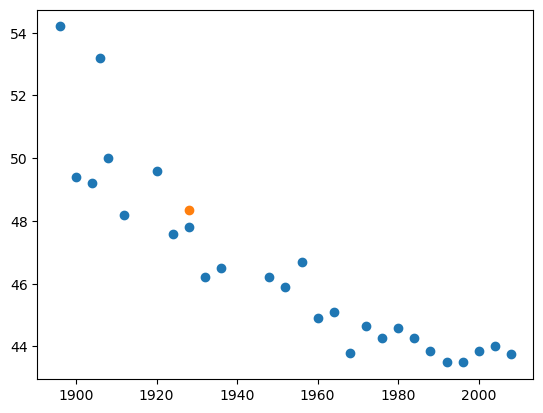

In [21]:
import matplotlib.pyplot as plt
plt.scatter(data_df.year.values, data_df.fastest_time.values)
plt.scatter(plot_x, plot_y)
plt.show()

In [22]:
your_data = [[2100, 35.42]]
year_yourdata, fastest_yourdata = scaler.transform(your_data)[0][0], scaler.transform(your_data)[0][1]
predict_yourdata = trainer.validate(data = torch.tensor([[year_yourdata], [fastest_yourdata]], dtype=torch.float32))
scaler.inverse_transform(np.asarray([[year_yourdata, fastest_yourdata], [year_yourdata, predict_yourdata.item()]]))
plot_x, plot_y = scaler.inverse_transform(np.asarray([[year_yourdata, fastest_yourdata], [year_yourdata, predict_yourdata.item()]]))[0]
plot_x_pred, plot_y_pred = scaler.inverse_transform(np.asarray([[year_yourdata, fastest_yourdata], [year_yourdata, predict_yourdata.item()]]))[1]

--------------------------------------------------------------------------------
tensor([-3.8478])
tensor([-3.7484], grad_fn=<AddBackward0>)
--------------------------------------------------------------------------------


/home/s-ach/miniconda3/envs/naamii_training/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/s-ach/miniconda3/envs/naamii_training/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
data_original[0]

(-1.6102583776090946, 2.6905969921790964)

In [24]:
data = [torch.tensor([[data_one_inside] for data_one_inside in data_one], dtype=torch.float32) for data_one in data_original]

In [25]:
data[1].shape

torch.Size([2, 1])

In [26]:
y_pred_overall = trainer.validate_all(data)

In [27]:
y_pred_overall[0]

tensor([1.4704], grad_fn=<AddBackward0>)

In [28]:
y_pred_overall = [y_pred_one for y_pred_one in y_pred_overall]

In [29]:
data_original[:][0]

array([-1.61025838, -1.49599563, -1.38173288, -1.3246015 , -1.26747013,
       -1.15320738, -0.92468188, -0.81041913, -0.69615638, -0.58189363,
       -0.46763088, -0.12484263, -0.01057988,  0.10368287,  0.21794561,
        0.33220836,  0.44647111,  0.56073386,  0.67499661,  0.78925936,
        0.90352211,  1.01778486,  1.13204761,  1.24631036,  1.36057311,
        1.47483586,  1.58909861])

In [30]:
overall_predicted_data_for_each_year_unscaled = [[year_data, fastest_data_year.item()] for year_data, fastest_data_year in zip(data_original[:][0], y_pred_overall)]
overall_predicted_data_for_each_year_unscaled

[[-1.6102583776090946, 1.4704383611679077],
 [-1.4959956280809854, 1.3681082725524902],
 [-1.3817328785528764, 1.2657781839370728],
 [-1.324601503788822, 1.2146131992340088],
 [-1.2674701290247674, 1.1634482145309448],
 [-1.1532073794966582, 1.0611181259155273],
 [-0.9246818804404401, 0.8564579486846924],
 [-0.8104191309123311, 0.7541278600692749],
 [-0.696156381384222, 0.6517978310585022],
 [-0.581893631856113, 0.5494677424430847],
 [-0.46763088232800387, 0.4471376836299896],
 [-0.12484263374367664, 0.14014750719070435],
 [-0.010579884215567579, 0.03781743720173836],
 [0.10368286531254149, -0.06451262533664703],
 [0.21794561484065056, -0.16684269905090332],
 [0.3322083643687596, -0.2691727578639984],
 [0.4464711138968687, -0.3715028464794159],
 [0.5607338634249778, -0.473832905292511],
 [0.6749966129530869, -0.5761629343032837],
 [0.7892593624811959, -0.6784930229187012],
 [0.903522112009305, -0.7808231115341187],
 [1.017784861537414, -0.8831531405448914],
 [1.132047611065523, -0.9854

In [31]:
overall_predicted_data_for_each_year_scaled = scaler.inverse_transform(np.asarray(overall_predicted_data_for_each_year_unscaled))
overall_predicted_data_for_each_year_scaled

array([[1896.        ,   50.69536267],
       [1900.        ,   50.40144199],
       [1904.        ,   50.10752132],
       [1906.        ,   49.96056115],
       [1908.        ,   49.81360098],
       [1912.        ,   49.51968031],
       [1920.        ,   48.93183896],
       [1924.        ,   48.63791828],
       [1928.        ,   48.34399778],
       [1932.        ,   48.0500771 ],
       [1936.        ,   47.75615651],
       [1948.        ,   46.87439475],
       [1952.        ,   46.58047412],
       [1956.        ,   46.28655352],
       [1960.        ,   45.99263289],
       [1964.        ,   45.6987123 ],
       [1968.        ,   45.40479163],
       [1972.        ,   45.11087104],
       [1976.        ,   44.81695053],
       [1980.        ,   44.52302986],
       [1984.        ,   44.22910918],
       [1988.        ,   43.93518868],
       [1992.        ,   43.641268  ],
       [1996.        ,   43.3473475 ],
       [2000.        ,   43.05342717],
       [2004.        ,   

In [32]:
overall_predicted_data_for_each_year_scaled[:,0]

array([1896., 1900., 1904., 1906., 1908., 1912., 1920., 1924., 1928.,
       1932., 1936., 1948., 1952., 1956., 1960., 1964., 1968., 1972.,
       1976., 1980., 1984., 1988., 1992., 1996., 2000., 2004., 2008.])

In [33]:
overall_predicted_data_for_each_year_scaled[:,1]

array([50.69536267, 50.40144199, 50.10752132, 49.96056115, 49.81360098,
       49.51968031, 48.93183896, 48.63791828, 48.34399778, 48.0500771 ,
       47.75615651, 46.87439475, 46.58047412, 46.28655352, 45.99263289,
       45.6987123 , 45.40479163, 45.11087104, 44.81695053, 44.52302986,
       44.22910918, 43.93518868, 43.641268  , 43.3473475 , 43.05342717,
       42.75950649, 42.46558581])

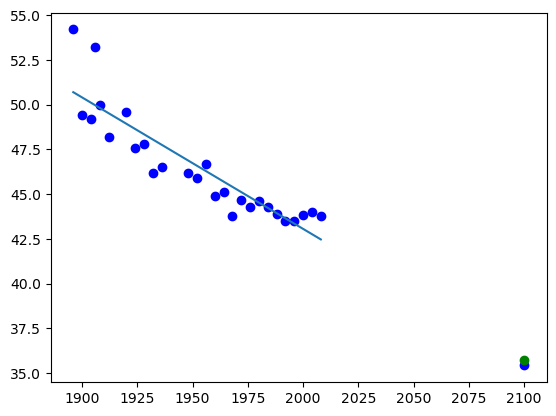

In [34]:
import matplotlib.pyplot as plt
plt.scatter(data_df.year.values, data_df.fastest_time.values, color='b')
plt.scatter(plot_x, plot_y, color='b')
plt.scatter(plot_x_pred, plot_y_pred, color='g')
plt.plot(overall_predicted_data_for_each_year_scaled[:,0], overall_predicted_data_for_each_year_scaled[:,1])
plt.show()

In [ ]:
# Append the values of year 2100 for each year unscaled

In [35]:
overall_predicted_data_for_each_year_unscaled.append([year_yourdata, predict_yourdata.item()])
overall_predicted_data_for_each_year_scaled = scaler.inverse_transform(np.asarray(overall_predicted_data_for_each_year_unscaled))


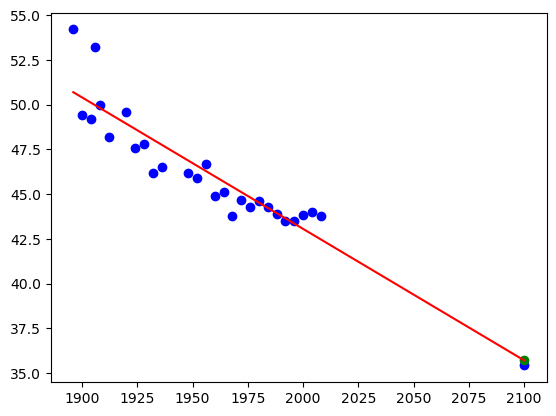

In [37]:
import matplotlib.pyplot as plt
plt.scatter(data_df.year.values, data_df.fastest_time.values, color='b')
plt.scatter(plot_x, plot_y, color='b')
plt.scatter(plot_x_pred, plot_y_pred, color='g')
plt.plot(overall_predicted_data_for_each_year_scaled[:,0], overall_predicted_data_for_each_year_scaled[:,1], color='r')
plt.show()

# Training a pytorch model for Single Layer NN

In [24]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch 
from sklearn.metrics import mean_squared_error
import numpy as np

In [25]:
class pytorch_model(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
    def forward(self, X):
        return self.linear(X)

In [26]:
linear_model = pytorch_model(1,1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(linear_model.parameters(), lr = 0.01)
max_epochs = 1000
batch_size = 1

In [27]:
class MyDataset(Dataset):
    def __init__(self, data):
        self.x, self.y = data[0], data[1]
        assert len(self.x) == len(self.y)
    def __getitem__(self, idx):
        sample = self.x[idx], self.y[idx]
        return sample
    def __len__(self):
        return len(self.x)

In [28]:
data = MyDataset(torch.tensor(([[1,2,3,4,5], [6,12,18,24,30]]), dtype = torch.float32))

num_train_sample = int(0.8 * len(data))
num_test_sample = len(data) - num_train_sample

train_data, test_data = random_split(data, [num_train_sample, num_test_sample])

In [29]:
train_loader, test_loader = DataLoader(train_data, batch_size, shuffle=True), DataLoader(test_data, batch_size, shuffle=False)

In [30]:
for epoch in range(max_epochs):
    train_loss, train_metric = [], []
    for batch in train_loader:
        x = batch[0]
        y = batch[1]
    optimizer.zero_grad()
    y_pred = linear_model(x)
    loss = criterion(y, y_pred)
    with torch.no_grad():
        loss.backward()
        metric = mean_squared_error(y, y_pred)
        train_loss.append(loss.item())
        train_metric.append(metric)
        optimizer.step()
        
    test_loss, test_metric = [], []
    for batch in test_loader:
        x = batch[0]
        y = batch[1]
        loss = criterion(y, y_pred)
        with torch.no_grad():
            metric = mean_squared_error(y, y_pred)
            test_loss.append(loss.item())
            test_metric.append(metric)

    print(f'At epoch : {epoch}') 
    print(f'Train Loss:{np.array(train_loss).mean()}, Train MSE: {np.array(train_metric).mean()}')
    print(f'Test Loss:{np.array(test_loss).mean()}, Test MSE: {np.array(test_metric).mean()}')

At epoch : 0
Train Loss:824.181884765625, Train MSE: 824.181884765625
Test Loss:22.17062759399414, Test MSE: 22.17062759399414
At epoch : 1
Train Loss:26.049945831298828, Train MSE: 26.049945831298828
Test Loss:0.8029688000679016, Test MSE: 0.8029688000679016
At epoch : 2
Train Loss:53.01926803588867, Train MSE: 53.01926803588867
Test Loss:22.264873504638672, Test MSE: 22.264873504638672
At epoch : 3
Train Loss:12.774351119995117, Train MSE: 12.774351119995117
Test Loss:5.884881973266602, Test MSE: 5.884881973266602
At epoch : 4
Train Loss:28.353164672851562, Train MSE: 28.353164672851562
Test Loss:44.55870819091797, Test MSE: 44.55870819091797
At epoch : 5
Train Loss:18.146034240722656, Train MSE: 18.146034240722656
Test Loss:59.91044616699219, Test MSE: 59.91044616699219
At epoch : 6
Train Loss:11.613456726074219, Train MSE: 11.613456726074219
Test Loss:73.82500457763672, Test MSE: 73.82500457763672
At epoch : 7
Train Loss:7.432614326477051, Train MSE: 7.432614326477051
Test Loss:86.

In [31]:
data = torch.tensor([[6], [36]], dtype=torch.float32)
linear_model.eval()
x = data[0]
y = data[1]
y_pred = linear_model(x)
print(y_pred)

tensor([35.7984], grad_fn=<ViewBackward0>)


# Exponential Model 

In [32]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch 
from sklearn.metrics import mean_squared_error
import numpy as np

In [33]:
class pytorch_model(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(in_features, hidden_features), 
            nn.ReLU(), 
            nn.Linear(hidden_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, out_features),
            nn.ReLU(),
        )
    def forward(self, X):
        output = self.linear(X)
        return output

In [34]:
exponential_model = pytorch_model(1, 8, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(exponential_model.parameters(), lr = 0.001)
max_epochs = 1000
batch_size = 1

In [35]:
class MyDataset(Dataset):
    def __init__(self, data):
        self.x, self.y = data[0], data[1]
        assert len(self.x) == len(self.y)
    def __getitem__(self, idx):
        sample = self.x[idx], self.y[idx]
        return sample
    def __len__(self):
        return len(self.x)

In [36]:
data = MyDataset(torch.tensor(([[1,2,3,4,5], [6,12,18,24,30]]), dtype = torch.float32))

num_train_sample = int(0.8 * len(data))
num_test_sample = len(data) - num_train_sample

train_data, test_data = random_split(data, [num_train_sample, num_test_sample])

In [37]:
train_loader, test_loader = DataLoader(train_data, batch_size, shuffle=True), DataLoader(test_data, batch_size, shuffle=False)

In [38]:
for epoch in range(max_epochs):
    train_loss, train_metric = [], []
    for batch in train_loader:
        x = batch[0]
        y = batch[1]
    optimizer.zero_grad()
    y_pred = exponential_model(x)
    loss = criterion(y, y_pred)
    with torch.no_grad():
        loss.backward()
        metric = mean_squared_error(y, y_pred)
        train_loss.append(loss.item())
        train_metric.append(metric)
        optimizer.step()
        
    test_loss, test_metric = [], []
    for batch in test_loader:
        x = batch[0]
        y = batch[1]
        loss = criterion(y, y_pred)
        with torch.no_grad():
            metric = mean_squared_error(y, y_pred)
            test_loss.append(loss.item())
            test_metric.append(metric)

    print(f'At epoch : {epoch}') 
    print(f'Train Loss:{np.array(train_loss).mean()}, Train MSE: {np.array(train_metric).mean()}')
    print(f'Test Loss:{np.array(test_loss).mean()}, Test MSE: {np.array(test_metric).mean()}')

At epoch : 0
Train Loss:861.37158203125, Train MSE: 861.37158203125
Test Loss:545.1820068359375, Test MSE: 545.1820068359375
At epoch : 1
Train Loss:827.9952392578125, Train MSE: 827.9952392578125
Test Loss:518.6963500976562, Test MSE: 518.6963500976562
At epoch : 2
Train Loss:26.126094818115234, Train MSE: 26.126094818115234
Test Loss:534.1353149414062, Test MSE: 534.1353149414062
At epoch : 3
Train Loss:771.4091796875, Train MSE: 771.4091796875
Test Loss:474.1181335449219, Test MSE: 474.1181335449219
At epoch : 4
Train Loss:236.01821899414062, Train MSE: 236.01821899414062
Test Loss:456.3728332519531, Test MSE: 456.3728332519531
At epoch : 5
Train Loss:18.725513458251953, Train MSE: 18.725513458251953
Test Loss:498.50830078125, Test MSE: 498.50830078125
At epoch : 6
Train Loss:622.318359375, Train MSE: 622.318359375
Test Loss:358.9626770019531, Test MSE: 358.9626770019531
At epoch : 7
Train Loss:56.32109069824219, Train MSE: 56.32109069824219
Test Loss:380.4347839355469, Test MSE: 38

In [39]:
data = torch.tensor([[6], [36]], dtype=torch.float32)
exponential_model.eval()
x = data[0]
y = data[1]
y_pred = exponential_model(x)
print(y_pred)

tensor([35.9550], grad_fn=<ReluBackward0>)
